In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,KFold,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


* In this notebook, I will try to predict students health so let's get started...

In [2]:
## Load the dataset
train_dataset = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
train_dataset.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## EDA

In [3]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

* In those columns : ["sleep_duration","heart_rate","bmi","calorie_expenditure","step_count","exercise_duration","water_intake","diet_type","stress_level","sleep_quality","physical_activity_level","smoking","gender"] we have missing values.

In [4]:
for column in train_dataset:
    print(f"{column} has , {train_dataset[column].isnull().sum()}")

id has , 0
health_condition has , 0
sleep_duration has , 75999
heart_rate has , 7833
bmi has , 13898
calorie_expenditure has , 52853
step_count has , 13916
exercise_duration has , 6901
water_intake has , 43477
diet_type has , 6901
stress_level has , 82811
sleep_quality has , 58331
physical_activity_level has , 36621
smoking_alcohol has , 28582
gender has , 21373


## Finding Categorical Variables

In [5]:
for column in train_dataset.columns:
    print(f"{column} has , -{train_dataset[column].nunique()}-unique values")

id has , -690088-unique values
health_condition has , -3-unique values
sleep_duration has , -701-unique values
heart_rate has , -537-unique values
bmi has , -1596-unique values
calorie_expenditure has , -2101-unique values
step_count has , -12807-unique values
exercise_duration has , -856-unique values
water_intake has , -400-unique values
diet_type has , -3-unique values
stress_level has , -3-unique values
sleep_quality has , -3-unique values
physical_activity_level has , -3-unique values
smoking_alcohol has , -3-unique values
gender has , -3-unique values


* Health_condition("Target"),Smoking_alcohol,gender,diet_type,stress_level,physical_activity_level have less than 5 so they are categorical variables...

In [6]:
train_dataset.drop("id",axis = 1,inplace = True)

In [7]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


In [8]:
numeric_columns = train_dataset.select_dtypes(include = ["float","int"]).columns.to_list()
numeric_columns

['sleep_duration',
 'heart_rate',
 'bmi',
 'calorie_expenditure',
 'step_count',
 'exercise_duration',
 'water_intake']

In [9]:
column_has_outlier = [ 'sleep_duration',
 'heart_rate',
 'bmi',
 'calorie_expenditure',
 'exercise_duration',
 'water_intake']

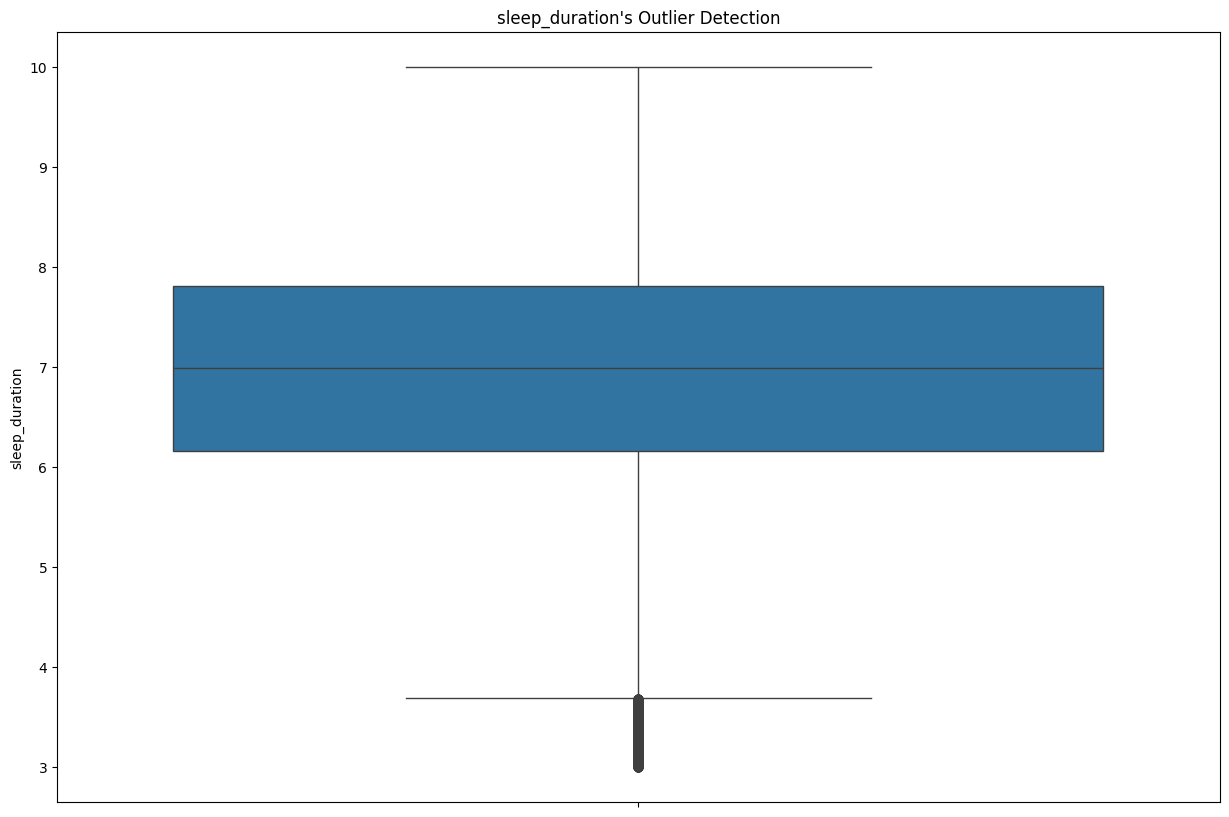

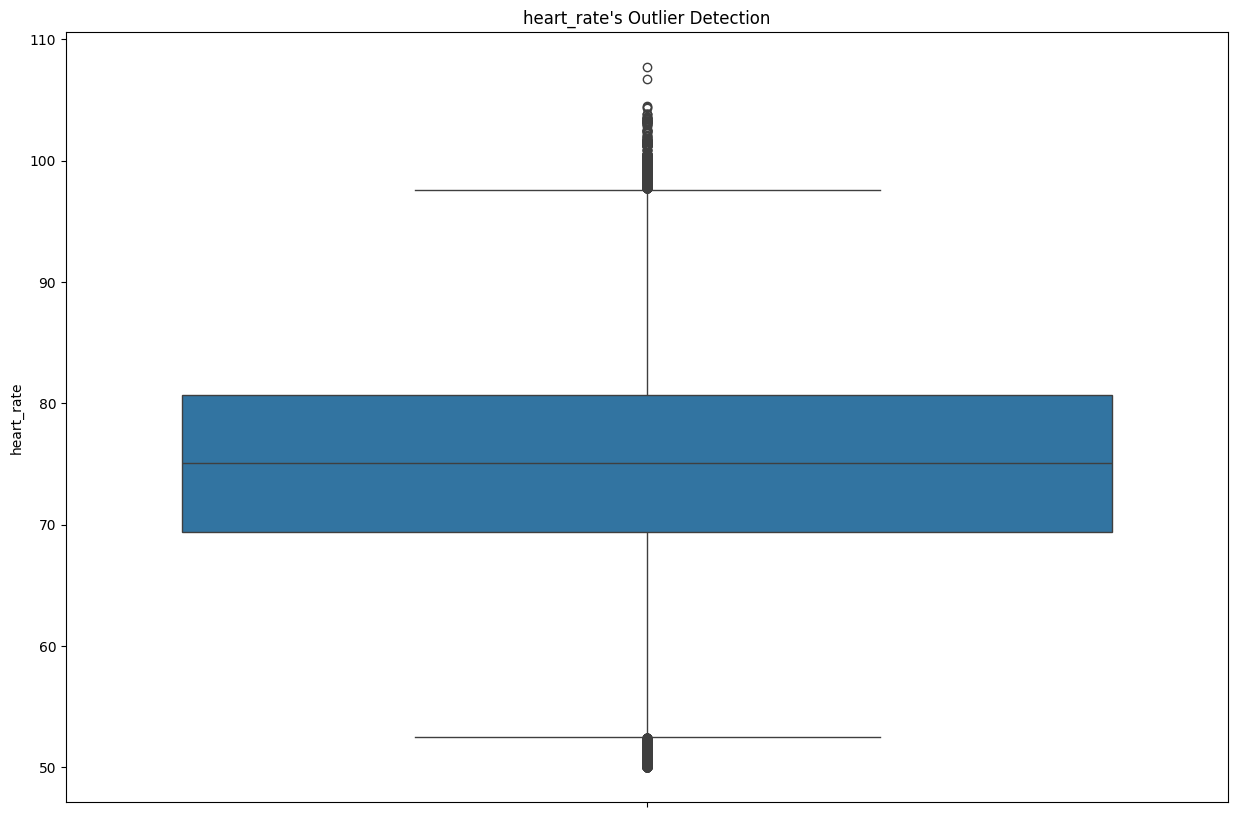

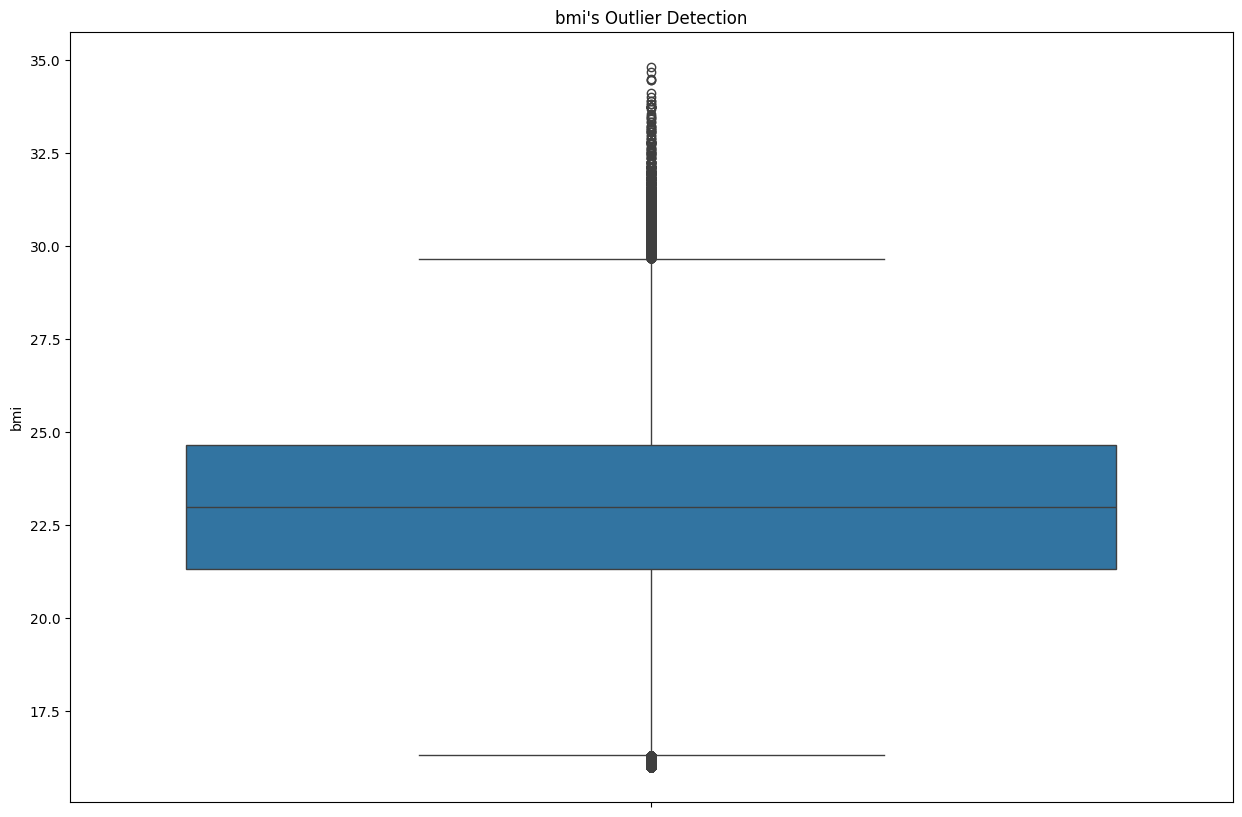

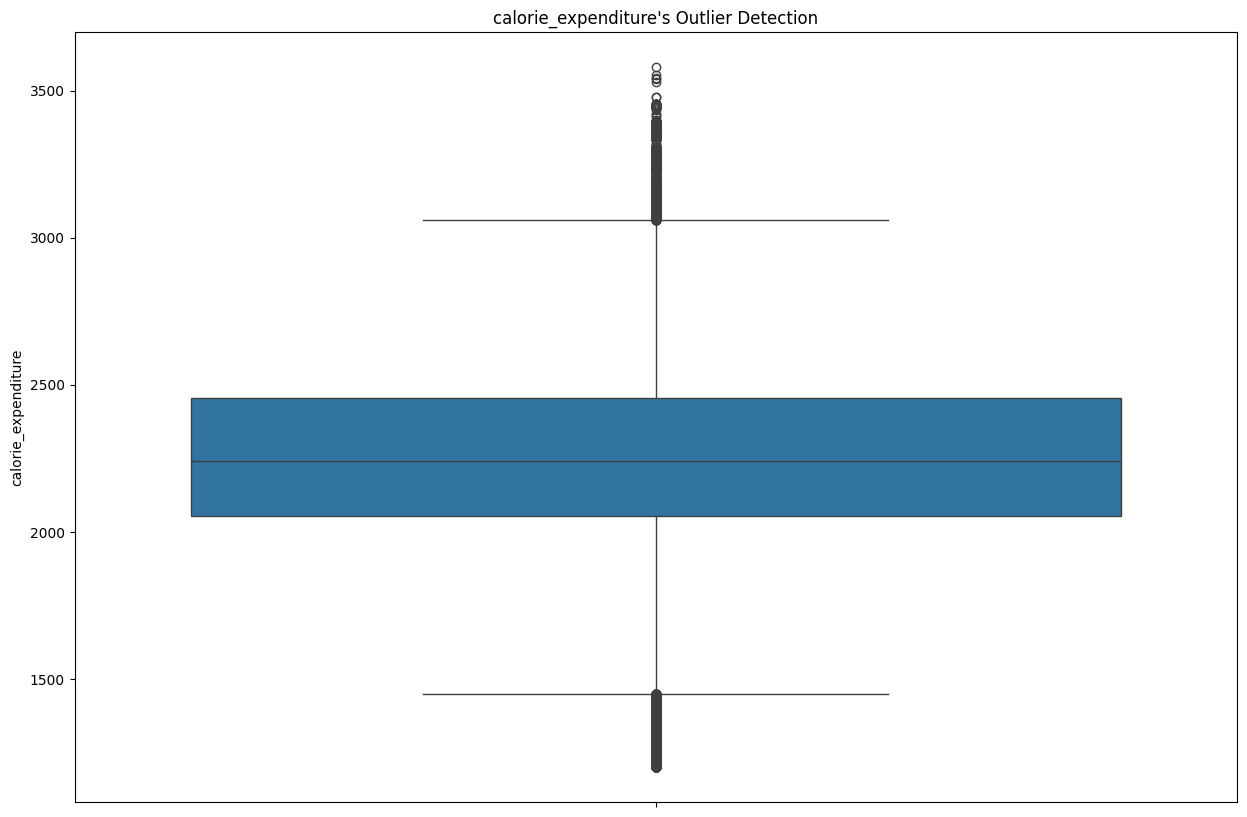

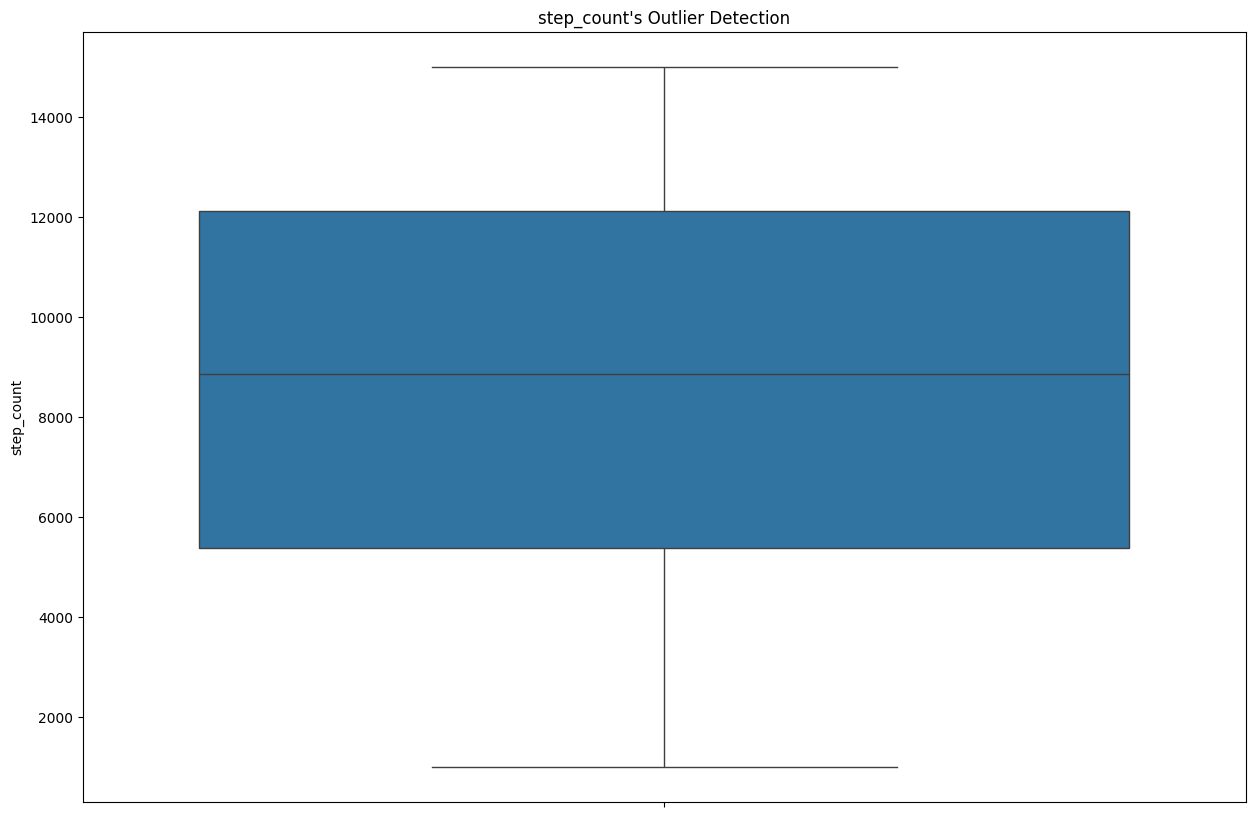

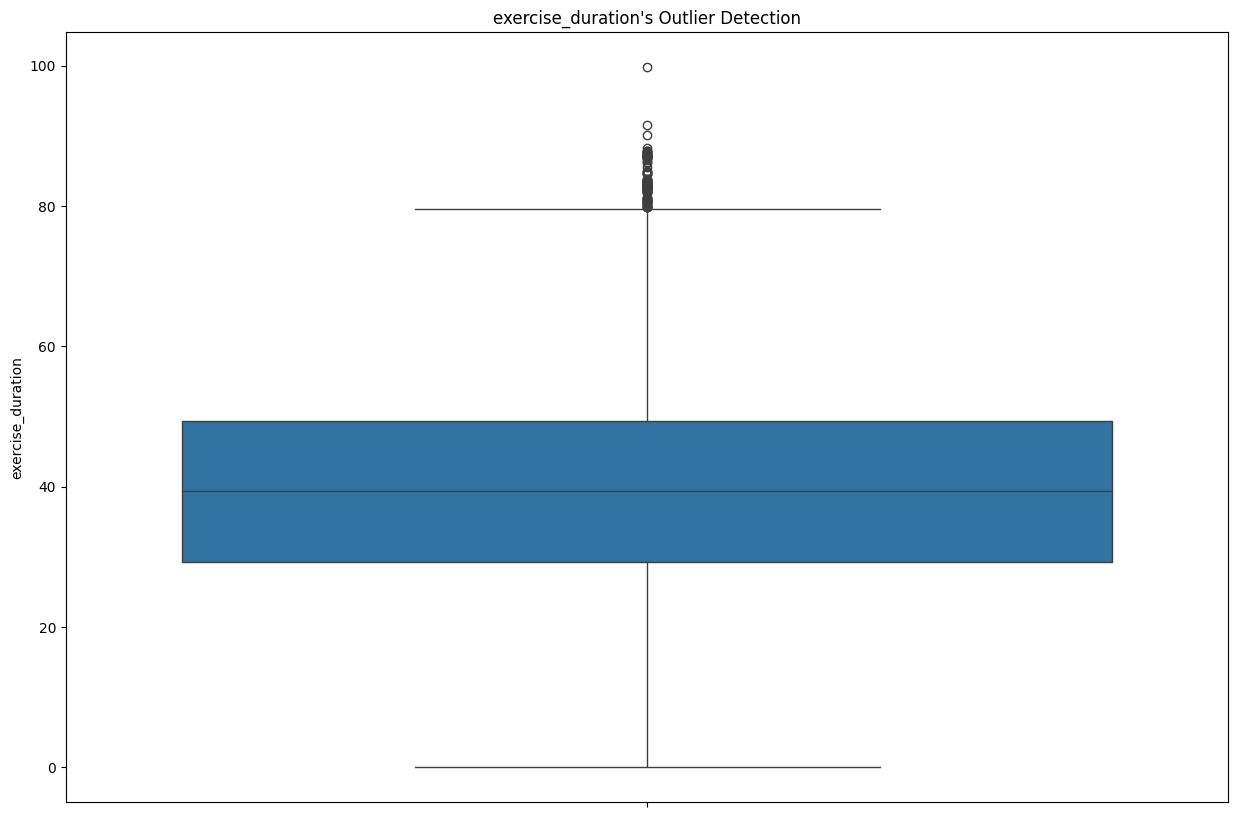

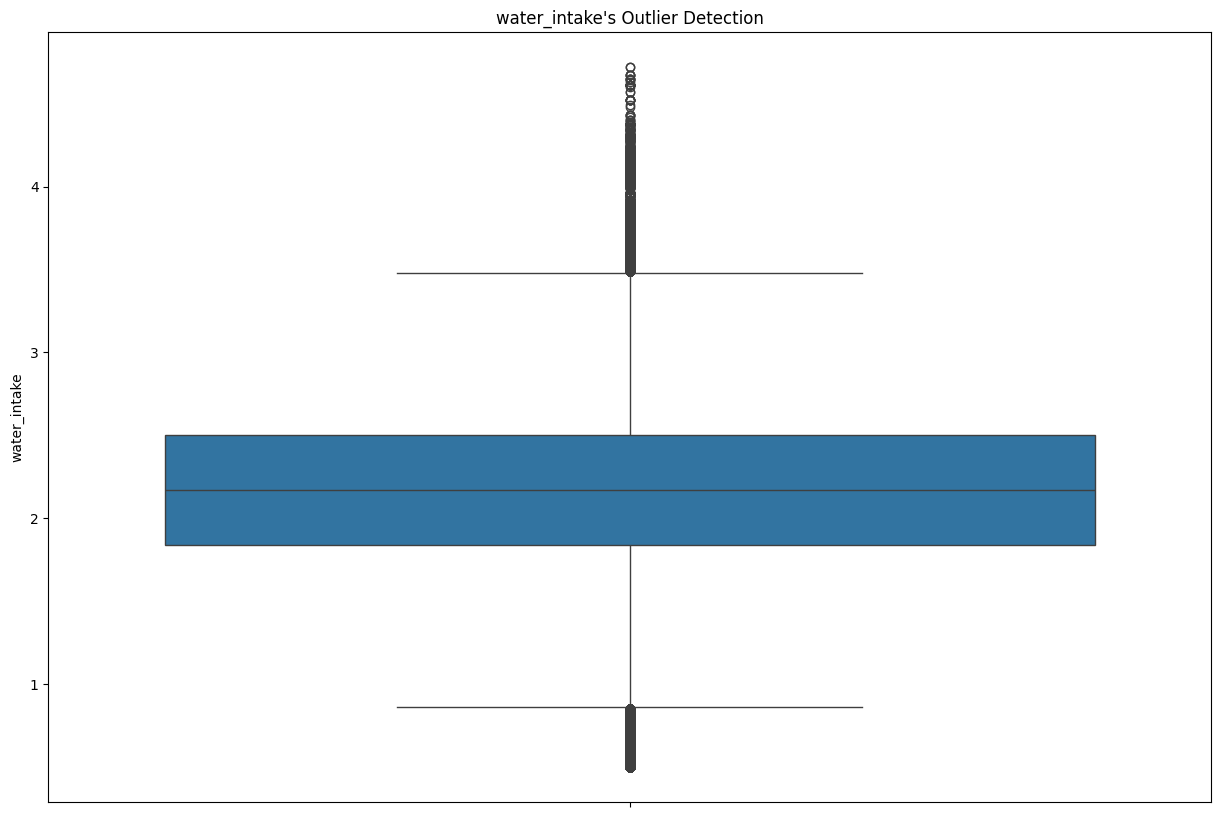

In [10]:
for column in numeric_columns:
    plt.figure(figsize = (15,10))
    plt.title(f"{column}'s Outlier Detection")
    sns.boxplot(data = train_dataset[column])
    plt.show()

* As we can see we have many outlier in numeric_variables so we have to fix it to maximize our model's performance...

## Fixing Missing Values

In [11]:
train_dataset.isnull().sum()

health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

* In the categorical variables, we could replace missing values with median values I suggest that...

In [12]:
numeric_columns = train_dataset.select_dtypes(include = ["float","int"]).columns
categoric_columns = train_dataset.select_dtypes(include = "object").columns
numeric_columns,categoric_columns


(Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
        'step_count', 'exercise_duration', 'water_intake'],
       dtype='object'),
 Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
        'physical_activity_level', 'smoking_alcohol', 'gender'],
       dtype='object'))

In [13]:
# Missing values of numeric values
for column in numeric_columns:
    train_dataset[column] = train_dataset[column].fillna(train_dataset[column].mean())
for c_column in categoric_columns:
    train_dataset[c_column] = train_dataset[c_column].fillna(train_dataset[c_column].mode()[0])
    

In [14]:
# Check there is any missing value in the dataset
train_dataset.isnull().sum(),train_dataset.isna().sum()

(health_condition           0
 sleep_duration             0
 heart_rate                 0
 bmi                        0
 calorie_expenditure        0
 step_count                 0
 exercise_duration          0
 water_intake               0
 diet_type                  0
 stress_level               0
 sleep_quality              0
 physical_activity_level    0
 smoking_alcohol            0
 gender                     0
 dtype: int64,
 health_condition           0
 sleep_duration             0
 heart_rate                 0
 bmi                        0
 calorie_expenditure        0
 step_count                 0
 exercise_duration          0
 water_intake               0
 diet_type                  0
 stress_level               0
 sleep_quality              0
 physical_activity_level    0
 smoking_alcohol            0
 gender                     0
 dtype: int64)

In [15]:
train_dataset["health_condition"].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [16]:
health = {"at-risk":1,"fit":2,"unhealthy":0}
train_dataset["health_condition"] = train_dataset["health_condition"].map(health)

In [17]:
train_dataset["health_condition"].value_counts()

health_condition
1    592561
0     57724
2     39803
Name: count, dtype: int64

In [18]:
# Convert the categoric variables to numeric variables
train_dataset = pd.get_dummies(train_dataset,dtype = "int")

In [19]:
train_dataset.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,...,sleep_quality_poor,physical_activity_level_active,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other
0,0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,0,...,0,0,0,1,0,0,1,1,0,0
1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,1,...,0,0,1,0,0,0,1,0,0,1
2,0,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,0,...,1,1,0,0,0,0,1,0,1,0
3,0,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0,0,...,0,1,0,0,0,1,0,1,0,0
4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0,0,...,0,0,0,1,0,0,1,0,1,0


In [20]:
train_dataset_ = train_dataset.copy()
for column in column_has_outlier:
    Q1 = train_dataset_[column].quantile(0.25)
    Q3 = train_dataset_[column].quantile(0.75)
    
    IQR = Q3-Q1
    lower_border = Q1-1.5*IQR
    upper_border = Q3+1.5*IQR
    
    train_dataset_[column] = np.where(train_dataset_[column] > upper_border, upper_border, train_dataset_[column])
    train_dataset_[column] = np.where(train_dataset_[column] < lower_border, lower_border, train_dataset_[column])

In [21]:
train_dataset_.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,...,sleep_quality_poor,physical_activity_level_active,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other
0,0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,0,...,0,0,0,1,0,0,1,1,0,0
1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,1,...,0,0,1,0,0,0,1,0,0,1
2,0,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,0,...,1,1,0,0,0,0,1,0,1,0
3,0,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0,0,...,0,1,0,0,0,1,0,1,0,0
4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0,0,...,0,0,0,1,0,0,1,0,1,0


In [22]:
train_dataset_["health_condition"].value_counts()

health_condition
1    592561
0     57724
2     39803
Name: count, dtype: int64

In [23]:
# Let's create our model
X = train_dataset_.drop("health_condition",axis = 1)
y = train_dataset_["health_condition"]
X,y

(        sleep_duration  heart_rate    bmi  calorie_expenditure   step_count  \
 0                 5.22        70.6  25.66               2174.0   1326.00000   
 1                 5.53        71.3  25.84               1966.0   9891.00000   
 2                 5.29        75.4  24.54               2688.0  14216.00000   
 3                 4.70        77.2  23.13               2630.0   7174.00000   
 4                 7.23        73.4  28.44               2560.0   6584.00000   
 ...                ...         ...    ...                  ...          ...   
 690083            6.31        69.7  24.11               2157.0   8615.95305   
 690084            5.78        54.0  26.36               2858.0   6488.00000   
 690085            7.64        85.7  21.91               2195.0   9241.00000   
 690086            6.74        73.0  18.73               2061.0  13366.00000   
 690087            5.55        69.3  24.38               2257.0   5144.00000   
 
         exercise_duration  water_inta

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state = 42)

In [25]:
# Use standardscaler to scale the variables
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)
X_train_scaled,X_test_scaled

(array([[ 1.3880803 ,  1.85215953,  0.31043991, ..., -0.69351127,
          1.28991881, -0.65441652],
        [ 0.10311789, -0.13503815, -0.60722083, ..., -0.69351127,
          1.28991881, -0.65441652],
        [ 1.22856772,  0.35867556, -1.73790996, ..., -0.69351127,
         -0.77524259,  1.52807879],
        ...,
        [-0.31338716, -1.08543704, -1.50439808, ..., -0.69351127,
          1.28991881, -0.65441652],
        [-0.41972888,  0.40804693, -1.64368587, ...,  1.44193763,
         -0.77524259, -0.65441652],
        [-1.11095003,  0.01307597,  1.37558184, ...,  1.44193763,
         -0.77524259, -0.65441652]]),
 array([[ 8.53942728e-02, -6.04066171e-01, -2.17625684e+00, ...,
          1.44193763e+00, -7.75242594e-01, -6.54416516e-01],
        [-1.33249528e+00, -9.99037138e-01, -8.44829420e-01, ...,
         -6.93511274e-01,  1.28991881e+00, -6.54416516e-01],
        [ 2.18321418e-01, -1.96752360e-01,  5.02984795e-01, ...,
         -6.93511274e-01,  1.28991881e+00, -6.54416516e-

In [26]:
dtf = DecisionTreeClassifier(max_depth = 7)
dtf.fit(X_train_scaled,y_train)
dtf_preds = dtf.predict(X_test_scaled)
print(f"Accuracy of the model : ",accuracy_score(y_test,dtf_preds))
print(f"Confusion Matrix of the model : ",confusion_matrix(y_test,dtf_preds))
print(f"Precision Score of the model : ",precision_score(y_test,dtf_preds,average = "macro"))
print(f"Recall Score of the model : ",recall_score(y_test,dtf_preds,average = "macro"))

Accuracy of the model :  0.9645263661261575
Confusion Matrix of the model :  [[  8681   2744     13]
 [   133 118165    323]
 [    23   1660   6276]]
Precision Score of the model :  0.9651998238541597
Recall Score of the model :  0.8478861516402999


In [27]:
xgb = XGBClassifier(learning_rate  = 0.03,
                   max_depth = 6,
                   n_estimators  = 600)
xgb.fit(X_train_scaled,y_train)
xgb_preds = xgb.predict(X_test_scaled)

print(f"Accuracy of the model : ",accuracy_score(y_test,xgb_preds))
print(f"Confusion Matrix of the model : ",confusion_matrix(y_test,xgb_preds))
print(f"Precision Score of the model : ",precision_score(y_test,xgb_preds,average = "macro"))
print(f"Recall Score of the model : ",recall_score(y_test,xgb_preds,average = "macro"))

Accuracy of the model :  0.9655914445941833
Confusion Matrix of the model :  [[  8951   2474     13]
 [   298 117996    327]
 [    22   1615   6322]]
Precision Score of the model :  0.9603183278204063
Recall Score of the model :  0.8572062984476195


In [28]:
lgb = LGBMClassifier(learning_rate  = 0.06,
                   max_depth = 6,
                   n_iterations  = 1500,
                    verbose = 300)
lgb.fit(X_train_scaled,y_train)
lgb_preds = lgb.predict(X_test_scaled)

print(f"Accuracy of the model : ",accuracy_score(y_test,lgb_preds))
print(f"Confusion Matrix of the model : ",confusion_matrix(y_test,lgb_preds))
print(f"Precision Score of the model : ",precision_score(y_test,lgb_preds,average = "macro"))
print(f"Recall Score of the model : ",recall_score(y_test,lgb_preds,average = "macro"))

[LightGBM] [Warning] Unknown parameter: n_iterations
[LightGBM] [Warning] Unknown parameter: n_iterations
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.733272
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.087993
[LightGBM] [Debug] init for col-wise cost 0.019564 seconds, init for row-wise cost 0.065359 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -2.478835
[LightGBM] [Info] Start training from score -0.152594
[LightGBM] [Info] Start training from score -2.852826
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy of the model :  0.9654900085496094
Confusion Matrix of the model :  [[  8844   2581     13]
 [   205 118076    340]
 [    24   1600   6335]]
Precision Score of the model :  0.96259357548808
Recall Score of the model :  0.8548573003016532


In [29]:
cbc =CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=4,
                           loss_function='MultiClass', random_state=42, verbose=100,auto_class_weights='SqrtBalanced')
cbc.fit(X_train_scaled,y_train)
cbc_preds = cbc.predict(X_test_scaled)
print(f"Accuracy of the model : ",accuracy_score(y_test,cbc_preds))
print(f"Confusion Matrix of the model : ",confusion_matrix(y_test,cbc_preds))
print(f"Precision Score of the model : ",precision_score(y_test,cbc_preds,average = "macro"))
print(f"Recall Score of the model : ",recall_score(y_test,cbc_preds,average = "macro"))

0:	learn: 1.0550935	total: 198ms	remaining: 3m 17s
100:	learn: 0.2677410	total: 13.4s	remaining: 1m 59s
200:	learn: 0.2242835	total: 26.4s	remaining: 1m 44s
300:	learn: 0.2116981	total: 39.3s	remaining: 1m 31s
400:	learn: 0.2064727	total: 52.1s	remaining: 1m 17s
500:	learn: 0.2036908	total: 1m 4s	remaining: 1m 4s
600:	learn: 0.2017297	total: 1m 17s	remaining: 51.7s
700:	learn: 0.2004633	total: 1m 30s	remaining: 38.7s
800:	learn: 0.1994661	total: 1m 43s	remaining: 25.7s
900:	learn: 0.1986026	total: 1m 56s	remaining: 12.8s
999:	learn: 0.1979297	total: 2m 9s	remaining: 0us
Accuracy of the model :  0.9597588720311844
Confusion Matrix of the model :  [[  9684   1738     16]
 [  1673 116213    735]
 [    29   1363   6567]]
Precision Score of the model :  0.9073014227743501
Recall Score of the model :  0.8838184072835776


### Test Set

In [30]:
test_dataset = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
test_dataset_ = test_dataset.copy()
test_dataset_.drop("id",axis = 1,inplace = True)
test_dataset_ = pd.get_dummies(test_dataset_,dtype = int)
test_dataset_ = Scaler.transform(test_dataset_)
sub_preds = cbc.predict(test_dataset_).flatten()
submission = pd.DataFrame({"id":test_dataset["id"],"health_condition":sub_preds})
health_rev = {1:"at-risk",2:"fit",0:"unhealthy"}
submission["health_condition"] = submission["health_condition"].map(health_rev)
submission.to_csv("submission.csv",index = False)